# Makemore part2: MLP - **Multi-Layer Perceptron**

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]


['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [5]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [145]:
# compile the dateset for the neural network
# dataset creation
block_size = 3 # context length: how many characters do we take to predict the next one
X, Y = [],[]
for w in words:
    #print(w)
    context = [0] * block_size
    for ch in w+'.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

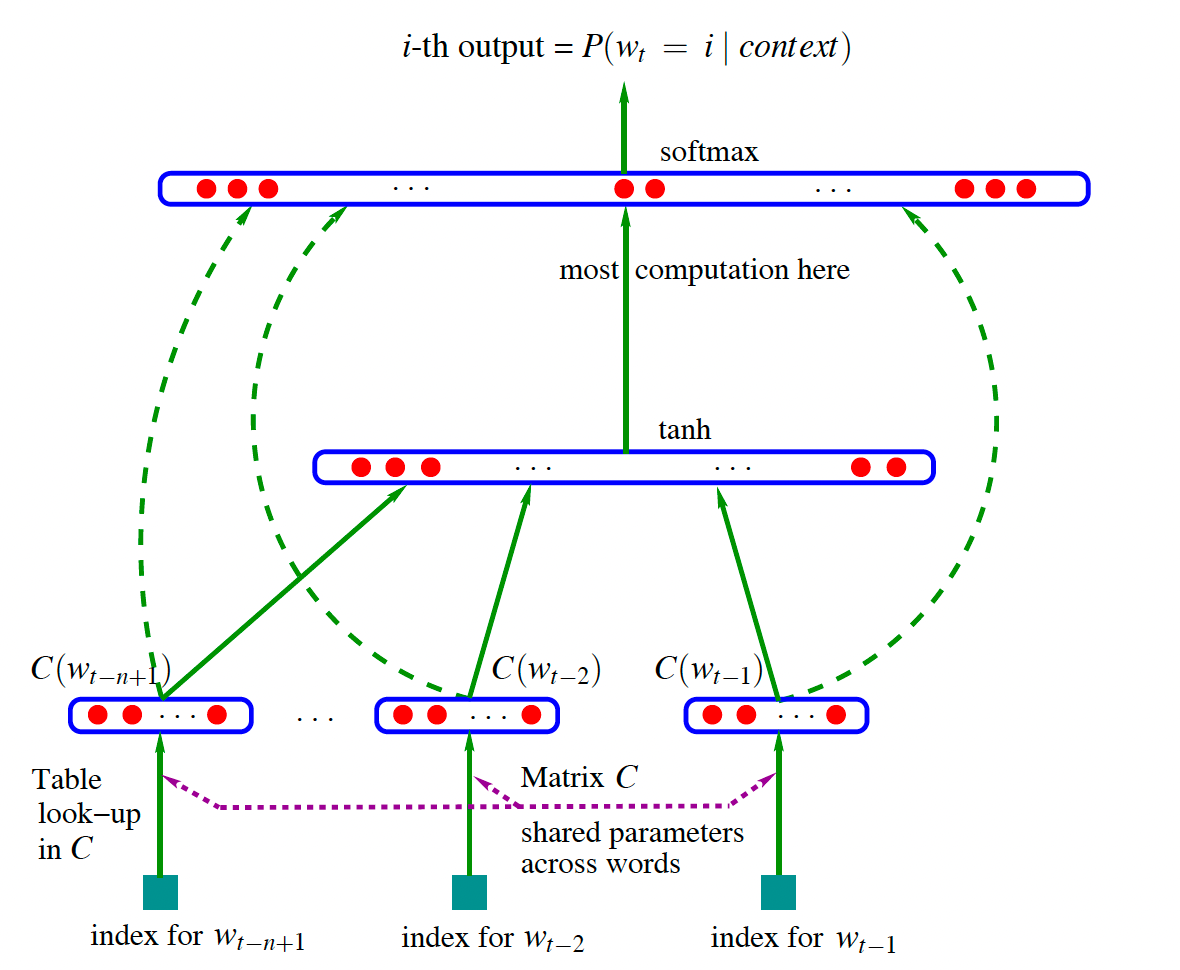

## Step 1: Build **Embedding Look-up Table C**

In [21]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [13]:
# embed the 27 chars into a lower dimensional space
C = torch.randn((27, 2)) # each of the 27 chars will have a 2D embedding 

In [14]:
C[5]

tensor([-0.3265, -0.0796])

In [20]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C # same result as C[5]

tensor([-0.3265, -0.0796])

In [23]:
C[X].shape

torch.Size([32, 3, 2])

In [61]:
emb = C[X] # this is the embed
emb

tensor([[[ 1.1268, -1.9736],
         [ 1.1268, -1.9736],
         [ 1.1268, -1.9736]],

        [[ 1.1268, -1.9736],
         [ 1.1268, -1.9736],
         [-0.3265, -0.0796]],

        [[ 1.1268, -1.9736],
         [-0.3265, -0.0796],
         [ 2.3111,  0.4889]],

        [[-0.3265, -0.0796],
         [ 2.3111,  0.4889],
         [ 2.3111,  0.4889]],

        [[ 2.3111,  0.4889],
         [ 2.3111,  0.4889],
         [ 0.2701, -0.4220]],

        [[ 1.1268, -1.9736],
         [ 1.1268, -1.9736],
         [ 1.1268, -1.9736]],

        [[ 1.1268, -1.9736],
         [ 1.1268, -1.9736],
         [ 1.5837, -1.1280]],

        [[ 1.1268, -1.9736],
         [ 1.5837, -1.1280],
         [ 0.2346,  0.7770]],

        [[ 1.5837, -1.1280],
         [ 0.2346,  0.7770],
         [-0.7683,  0.8521]],

        [[ 0.2346,  0.7770],
         [-0.7683,  0.8521],
         [-1.2394, -0.9962]],

        [[-0.7683,  0.8521],
         [-1.2394, -0.9962],
         [-0.7683,  0.8521]],

        [[-1.2394, -0

## Step 2: Build **The hidden layor:** `tanh`

In [62]:
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In order to be able to calculate **`emb @ W1 + b1`**, we need to convert the emb from (32, 3, 2) to (32, 6)

In [63]:
torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]], 1).shape

torch.Size([32, 6])

In [68]:
torch.cat(torch.unbind(emb, 1), 1).shape # the same as "torch.cat([emb[:,0,:], emb[:,1,:], emb[:,2,:]], 1)" but more practical

torch.Size([32, 6])

### Efficiency: emb.view() >>>>> torch.cat

**`emb.view()`** only changes the way of reading without changing what is stored in the memory.

**`torch.cat`** creates new tensors in memory so it uses way mnore memories.

In [ ]:
# using view
emb.view(32,6) == torch.cat(torch.unbind(emb, 1), 1) 

In [76]:
h = torch.tanh(emb.view(emb.shape[0], 6) @ W1 + b1)

## Step 3: Build **The final layor:** `softmax`

In [78]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [79]:
logits = h @ W2 + b2

In [81]:
logits.shape

torch.Size([32, 27])

In [82]:
counts = logits.exp()

In [94]:
prob = counts / counts.sum(1, keepdims=True)

In [95]:
prob.shape

torch.Size([32, 27])

In [96]:
loss = -prob[torch.arange(32), Y].log().mean() # negative log likelihood same as in the last note
loss

tensor(22.0540)

#### Tidy up

In [146]:
X.shape,Y.shape # dataset

(torch.Size([228146, 3]), torch.Size([228146]))

In [180]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [163]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [100]:
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) #(32, 100)
logits = h @ W2 + b2
#counts = logits.exp()
#prob = counts / counts.sum(1, keepdims=True)
#loss = -prob[torch.arange(32), Y].log().mean()
loss = F.cross_entropy(logits, Y) # this line works the same way as the 3 commented lines above
loss

tensor(17.7697)

**Reasons of using `cross_entropy` instead of the 3 seperate lines:**

* **`1`**: While using `cross_entropy`, pytorch won't create intermediate tensors, it will cluster up all the operations and have fused kernels that efficiently evaluates these expressions.

* **`2`**: The backward pass can be much more efficient, analytically and mathematically it's a much simpler backward pass to implement (example with   `tanh` in note1)

* **`3`**: `F.cross_entropy` can also be numerically well behaved(prove below)

In [109]:
# prove
logits = torch.tensor([-5, -3, 0, 100]) - 100 # pytorch will subtract the Max number in the tensor to make sure it can work properly
counts = logits.exp() # passing a big positif number can run out of range in out floating point number
probs = counts / counts.sum()
probs

tensor([0.0000e+00, 1.4013e-45, 3.7835e-44, 1.0000e+00])

### Set up the training for the neural net

In [181]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre # we want the learning rate between [0.001, 1]
#lrs # these are the candidates of the learning rate that we want to search over

In [191]:
# keep track of the learning rates and the losses
lri = []
lossi = []

for p in parameters:
    p.requires_grad = True
for i in range(100000):
    # minibatch construct
    ix = torch.randint(0, X.shape[0], (32,))
    # forward pass
    emb = C[X[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) #(32, 100)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix]) 
    # print('loss: ', loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    #lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    #lri.append(lre[i])
    #lossi.append(loss.item())

print(loss.item()) # overfitting the 32 examples with 3481 parameters(when we take only the first 5 words)

2.333832263946533


In [192]:
# check the whole loss after the minibatch
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) #(32, 100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Y) 
loss

tensor(2.2098, grad_fn=<NllLossBackward0>)

In [ ]:
plt.plot(lri, lossi)

So from the plot we can see that around lr = 0.1 is the best

#### improve the training by using random mini-batchs to iterate

In [ ]:
# this create 32 integers that index into our dataset 
torch.randint(0, X.shape[0], (32,))

### How to determine the learning rate in p.data += -`0.1` * p.grad

In [ ]:
lre = torch.linspace(-3, 0, 1000) # learning rate exponent
lrs = 10**lre # we want the learning rate between [0.001, 1]
lrs # these are the candidates of the learning rate that we want to search over

### Learning rate deacy

take the present learning rate then 10x lower it, so we're at the late stages of training potentially

In porduction(roughly):
* `1`: Find a decent learning rate(with the approch above).
* `2`: Training....
* `3`: Learning rate decay
* `4`: Training a bit....
* `5`: Get a Trained NN!!!

### Data into 3 splits:

**`Training split`** (80%): To optimize the parameters of the model using gradient descent

**`Dev/Validation split`** (10%): Used for the development over all the `hyper paramsters`(size of hidden layor, size of the embedding) of the model. To train `hyper` parameters.

**`Test split`** (10%): To evaluate the performance of the model at the end. (Attention; evaluate on tests very very sparingly to avoid overfitting to it!)

In [223]:
# build the dataset
words = open('names.txt', 'r').read().splitlines()
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) # training split
Xdev, Ydev = build_dataset(words[n1:n2]) # dev split
Xte, Yte = build_dataset(words[n2:]) # test split

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [197]:
Xtr.shape,Ytr.shape # dataset for training
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre 
# keep track of the learning rates and the losses
lri = []
lossi = []

for p in parameters:
    p.requires_grad = True
for i in range(100000):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))
    # forward pass
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) #(32, 100)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix]) 
    # print('loss: ', loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    #lr = lrs[i]
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad


print(loss.item()) # overfitting the 32 examples with 3481 parameters(when we take only the first 5 words)

2.333174467086792


In [198]:
# check the loss on the training set
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) #(32, 100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr) 
loss

tensor(2.4133, grad_fn=<NllLossBackward0>)

In [199]:
# check the loss on the dev set
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) #(32, 100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev) 
loss

tensor(2.4102, grad_fn=<NllLossBackward0>)

After comparing the loss of on the training set and the dev set, it's roughly the same, meaning that the model is not overfitting. We're having an underfitting here. 

Meaning that our network is very tiny, we can expect performance improvements by scaling up the size of this neural network.

In [224]:
Xtr.shape,Ytr.shape # dataset for training
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]


In [225]:
# number of parameters after scaling up
sum(p.nelement() for p in parameters) # number of parameters in total

10281

In [226]:
#lre = torch.linspace(-3, 0, 1000)
#lrs = 10**lre 
# keep track of the learning rates and the losses
lri = []
lossi = []

# keep track of steps
stepi = []

for p in parameters:
    p.requires_grad = True
for i in range(100000):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))
    # forward pass
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) #(32, 100)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix]) 
    # print('loss: ', loss.item())
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    #lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    stepi.append(i)
    lossi.append(loss.item())


print(loss.item()) # overfitting the 32 examples with 3481 parameters(when we take only the first 5 words)

2.215815305709839


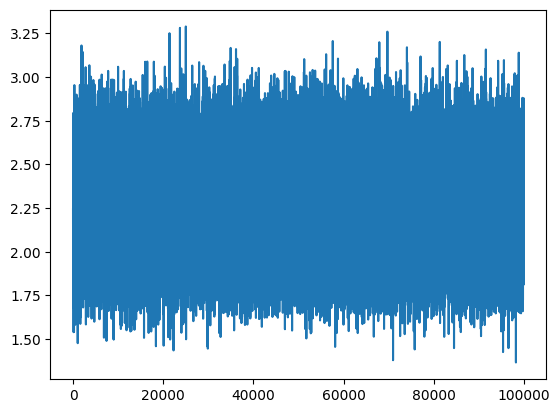

In [215]:
plt.plot(stepi, lossi)

In [228]:
# check the loss on the training set and the dev one
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) #(32, 100)
logits = h @ W2 + b2
losstr = F.cross_entropy(logits, Ytr) 
print('training loss: ', losstr)

emb = C[Xdev]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) #(32, 100)
logits = h @ W2 + b2
lossdev = F.cross_entropy(logits, Ydev) 
print('dev loss: ', lossdev)

training loss:  tensor(2.3838, grad_fn=<NllLossBackward0>)
dev loss:  tensor(2.3831, grad_fn=<NllLossBackward0>)


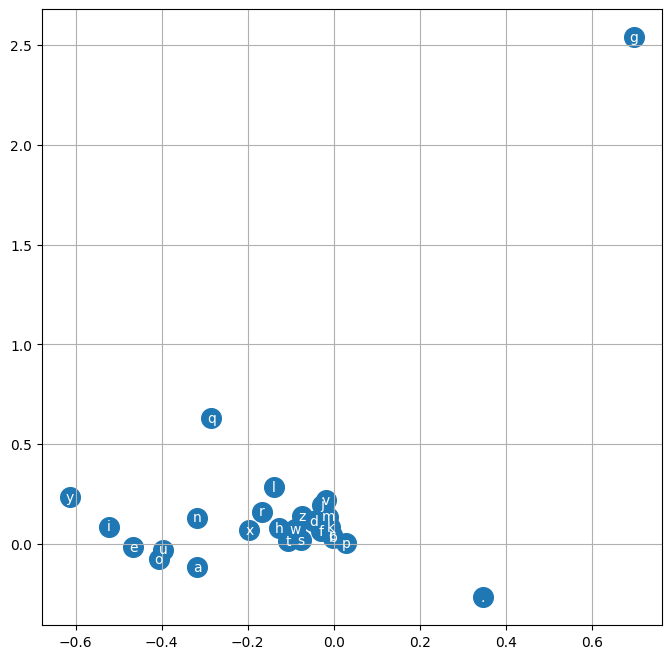

In [229]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

Now we're going to scale up the dimension of embeddings

In [232]:
Xtr.shape,Ytr.shape # dataset for training
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27,10), generator=g) # scale up the embedding dimension
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [233]:
# number of parameters after scaling up
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [234]:
#lre = torch.linspace(-3, 0, 1000)
#lrs = 10**lre 
# keep track of the learning rates and the losses
lri = []
lossi = []

# keep track of steps
stepi = []


In [248]:

for p in parameters:
    p.requires_grad = True
for i in range(100000):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))
    # forward pass
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) #(32, 100)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[ix]) 
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    # update
    #lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    stepi.append(i)
    lossi.append(loss.log10().item())


print(loss.item()) # overfitting the 32 examples with 3481 parameters(when we take only the first 5 words)

2.260087013244629


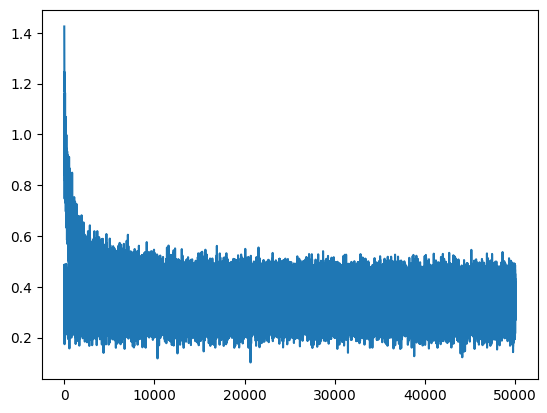

In [243]:
plt.plot(stepi, lossi)

In [249]:
# check the loss on the training set and the dev one
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) #(32, 100)
logits = h @ W2 + b2
losstr = F.cross_entropy(logits, Ytr) 
print('training loss: ', losstr)

emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) #(32, 100)
logits = h @ W2 + b2
lossdev = F.cross_entropy(logits, Ydev) 
print('dev loss: ', lossdev)

training loss:  tensor(2.1138, grad_fn=<NllLossBackward0>)
dev loss:  tensor(2.1552, grad_fn=<NllLossBackward0>)


In [ ]:
# cleaned code, hasn't run yet

for i in range(200000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))
  
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())

In order to train the model better, there are sevral things to change:

* **`1`:** The number of neurons in the hidden layer of the model(tanh)

* **`2`:** The diemnsionality of the embedding lookup table

* **`3`:** The number of chars as input

* **`4`:** Details of the optimization(number of iterations, learning rate, how lr decay, batch size etc)

In [250]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carlah.
amelle.
khy.
miliatalynn.
cassie.
mahnee.
deliah.
jareei.
nellara.
chaiir.
kaleigh.
ham.
joce.
quinn.
suline.
kianni.
wanell.
dearynix.
kael.
dusti.
